In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Set Chinese font and style
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['axes.edgecolor'] = 'black'   # Spine color
plt.rcParams['axes.linewidth'] = 1.0       # Spine width
plt.rcParams['axes.grid'] = False        # Master switch

Original data count: 1003
Filtered data count (k<10): 970
k range: [0.200, 9.927]
Feature missing values count: 0
Target variable missing values count: 0
Training set size: (776, 132)
Testing set size: (194, 132)


C:\Users\wangshuaijie\PycharmProjects\JupyterProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\wangshuaijie\PycharmProjects\JupyterProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training set RMSE: 0.779
Testing set RMSE: 1.061
Training set R²: 0.878
Testing set R²: 0.780


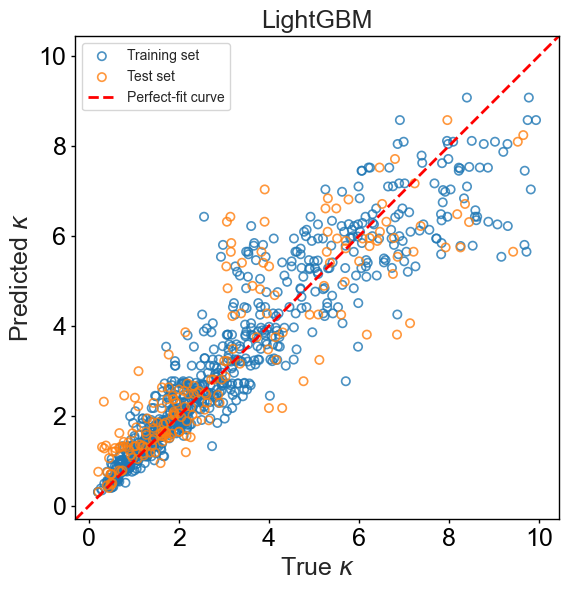

In [3]:
# Read data
df = pd.read_csv('csv/df_k.csv')

# Filter data with k less than 10
df_filtered = df[df['k(W/mK)'] < 10].copy()

print(f"Original data count: {len(df)}")
print(f"Filtered data count (k<10): {len(df_filtered)}")
print(f"k range: [{df_filtered['k(W/mK)'].min():.3f}, {df_filtered['k(W/mK)'].max():.3f}]")

# Prepare features and labels
feature_columns = [col for col in df.columns if col.startswith('MagpieData')]
X = df_filtered[feature_columns]
y = df_filtered['k(W/mK)']

# Check for missing values
print(f"Feature missing values count: {X.isnull().sum().sum()}")
print(f"Target variable missing values count: {y.isnull().sum()}")

# If there are missing values, fill with mean
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
if y.isnull().sum() > 0:
    y = y.fillna(y.mean())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=-1,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train model
lgb_model.fit(X_train_scaled, y_train)

# Predict
y_train_pred = lgb_model.predict(X_train_scaled)
y_test_pred = lgb_model.predict(X_test_scaled)

# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training set RMSE: {train_rmse:.3f}")
print(f"Testing set RMSE: {test_rmse:.3f}")
print(f"Training set R²: {train_r2:.3f}")
print(f"Testing set R²: {test_r2:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)
#
# print("\nTop 10 important features:")
# print(feature_importance.head(10))

fig, ax = plt.subplots(figsize=(7, 6))

ax.tick_params(axis='both',          # Operate on both x and y axes
               which='major',        # Major ticks (minor ticks similarly)
               direction='out',       # Ticks inward, out/both also possible
               length=3,             # Tick length
               width=1.0,            # Tick width
               colors='black')       # Tick color

# 1. Training set: hollow blue circles
ax.scatter(y_train, y_train_pred,
           facecolors='none',
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label='Training set')

# 2. Test set: hollow orange circles
ax.scatter(y_test, y_test_pred,
           facecolors='none',
           edgecolors='tab:orange',
           linewidth=1.2,
           alpha=0.8,
           label='Test set')

# 3. Perfect fit line
lim = [min(y_train.min(), y_test.min()) - 0.5,
       max(y_train.max(), y_test.max()) + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Perfect-fit curve')

# 4. Styling
ax.set_xlabel(r'True $\kappa$', fontsize=18)
ax.set_ylabel(r'Predicted $\kappa$', fontsize=18)
ax.set_title('LightGBM', fontsize=18)
ax.legend()



# 6. Equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

# 7. Show tick marks
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=18)

plt.tight_layout()
plt.show()